# Mateus Ribeiro - 555225
## Trabalho Clusterização

In [220]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

É necessário padronizar as features pois há atribuitos que possuem uma grande diferença na ordem de grandeza, o que prejudica o desempenho dos algoritmos.

Ex: segundos de uso esta na casa dos milhares e call na casa das dezenas.

In [221]:
data = pd.read_csv('./CustomerChurn.csv')
X = data.drop(['Churn'], axis=1) 
y_churn = data['Churn'] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Pair plot dos atributos para analisar como estão relacionados e a distribuição de cada

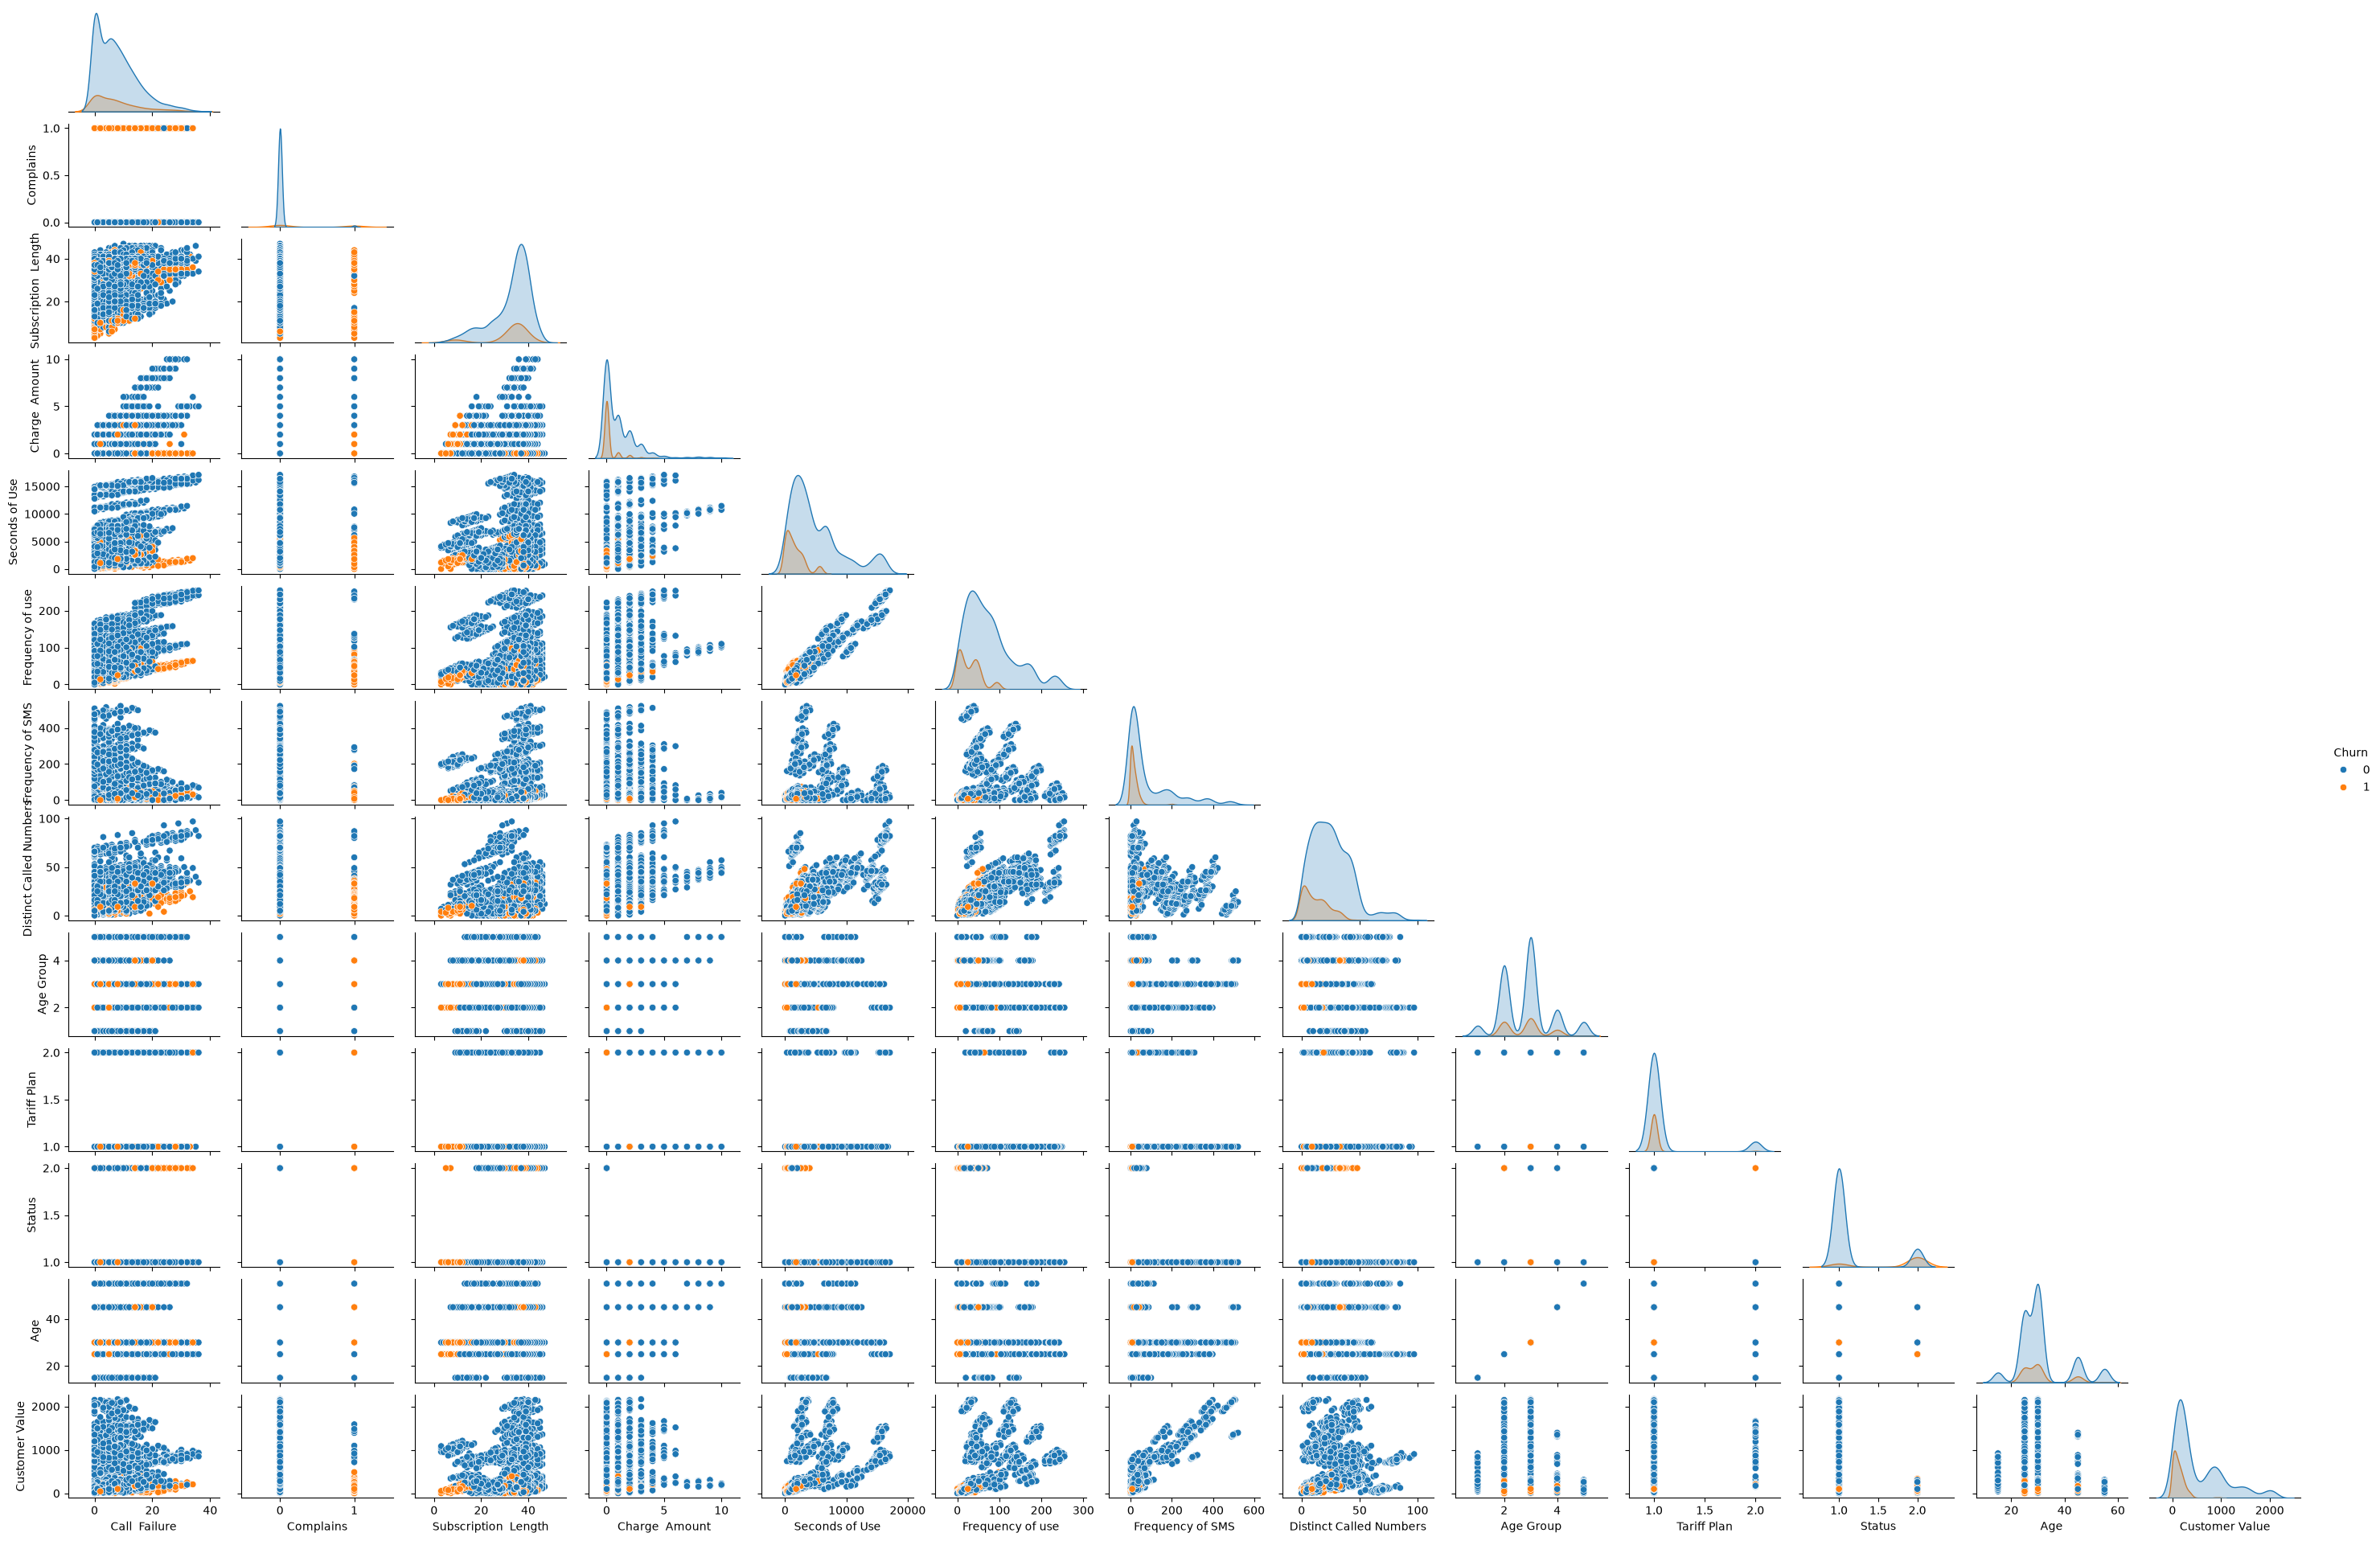

In [222]:
sns.pairplot(data, hue='Churn', corner=True,height=1.5, aspect=1.5)

## Implementação do K means

O algoritmo segue o seguinte fluxo:

1. Os centroides são inicializados de maneira aleatória.
2. Calcula-se a distância de cada ponto para todos os centroides, e cada ponto é atribuído ao que apresentar a menor distância.
3. Calcula-se a média espacial de todos os pontos que foram atribuídos a cada centroide.
4. O novo centroide passa a ser esse valor da média calculada.
5. Repete-se o processo iterativamente até que os centroides parem de mudar de posição (convergência) ou até que se atinja o limite máximo de iterações especificado.

In [223]:
class Kmedias:
    def __init__(self, num_clusters, num_iter, dist_type, seed=None):
        self.num_clusters = num_clusters
        self.iter = num_iter
        self.inv_cov = None
        self.dist_type = dist_type
        self.seed = seed 
        self.centroides = None

    def train(self, X):
        if self.dist_type == "mahalanobis":
            cov = np.cov(X, rowvar=False)
            try:
                self.inv_cov = np.linalg.inv(cov)
            except np.linalg.LinAlgError:
                self.inv_cov = np.linalg.pinv(
                    cov
                )  # Usa pseudo inversa como contingencia

        # definindo os centroides iniciais selecionando pontos aleatorios do conjunto
        if self.seed is not None:
                np.random.seed(self.seed)

        indices_iniciais = np.random.choice(
            X.shape[0], self.num_clusters, replace=False
        )
        self.centroides = X[indices_iniciais]

        for _ in range(self.iter):
            centroides_anteriores = self.centroides.copy()

            # Agrupa os pontos aos centroides correspondentes
            labels = self._atribuir_clusters(X)

            # Reposiciona os centroides calculando a media de cada grupo
            self.centroides = self._atualizar_centroides(X, labels)

            # para automaticamente se os valores parerem de ser atualizados 
            if np.all(centroides_anteriores == self.centroides):
                break

        return labels, self.centroides

    def _atribuir_clusters(self, X):
        labels = []
        for ponto in X:
            distancias = []
            for centroide in self.centroides:
                if self.dist_type == "euclidian":
                    dist = self._euclidian(ponto, centroide)
                elif self.dist_type == "mahalanobis":
                    dist = self._mahalanobis(ponto, centroide)
                elif self.dist_type == "manhatam":
                    dist = self._manhatam(ponto, centroide)
                distancias.append(dist)

            # posicao do centroide que apresentou a menor distancia
            labels.append(np.argmin(distancias))

        return np.array(labels)

    def _atualizar_centroides(self, X, labels):
        novos_centroides = np.zeros((self.num_clusters, X.shape[1]))
        for k in range(self.num_clusters):
            # pega os pontos atribuidos a cada centroide anteriormente
            pontos_do_grupo = X[labels == k]

                # atualiza o centroide com a media dos pontos preivamente atribuidos a ele
            novos_centroides[k] = np.mean(pontos_do_grupo, axis=0)

        return novos_centroides

    def _euclidian(self, p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))

    def _mahalanobis(self, p1, p2):
        diff = np.array(p1) - np.array(p2)
        dist = np.sqrt(np.dot(np.dot(diff, self.inv_cov), diff.T))
        return dist

    def _manhatam(self, p1, p2):
        return np.sum(np.abs(p1-p2))

### Uso do PCA para plot em 2 dimensões

É válido ressaltar que para que pudéssemos visualizar o gráfico dos cluster para cada método e cada métrica adotada, fez-se necessária a utilizacão da análise de componentes principais para redução de dimensionalidade. O PCA foi utilizado apenas para visualização, sendo aplicado tanto no conjunto normalizado `X` quanto nos centroides. Os modelos foram treinados utilizando os conjunto de dados com dimensão original, ou seja, 13 atributos

Vamos definir alguns valores para K para que possamos futuramente analisar o gráfico de cotovelo para todas as metricas de distância utilizadas (descritas a seguir), o valor de K escolhido representa a quantidade de centroides inicializados

#### Testando com distância euclidiana $$d = \sqrt{\sum (x_i-y_i)^2} $$

In [224]:
def train_and_plotelbow(dist_type):
    ks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    js = []

    for k in ks:
        kmeans = Kmedias(num_clusters=k, num_iter=100, dist_type=dist_type, seed=23)
        labels, centroides = kmeans.train(X_scaled)

        J = 0
        for i, ponto in enumerate(X_scaled):
            centroide_atribuido = centroides[labels[i]]
            
            if kmeans.dist_type == "euclidian":
                dist = kmeans._euclidian(ponto, centroide_atribuido)
            elif kmeans.dist_type == "mahalanobis":
                dist = kmeans._mahalanobis(ponto, centroide_atribuido)
            elif kmeans.dist_type == "manhatam":
                dist = kmeans._manhatam(ponto, centroide_atribuido)
                
            J += dist ** 2
            
        js.append(J)
        print(f"K={k} treinado. Inércia: {J:.2f}")

    plt.figure(figsize=(10, 6))
    plt.plot(ks, js, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
    plt.title(f'Método do Cotovelo para distancia {dist_type}', fontsize=14)
    plt.xlabel('k', fontsize=12)
    plt.ylabel('Inércia (J)', fontsize=12)
    plt.xticks(ks)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

K=1 treinado. Inércia: 40950.00
K=2 treinado. Inércia: 32274.18
K=3 treinado. Inércia: 28610.57
K=4 treinado. Inércia: 25165.60
K=5 treinado. Inércia: 22247.21
K=6 treinado. Inércia: 19386.66
K=7 treinado. Inércia: 18174.19
K=8 treinado. Inércia: 16682.94
K=9 treinado. Inércia: 15295.90
K=10 treinado. Inércia: 14124.16


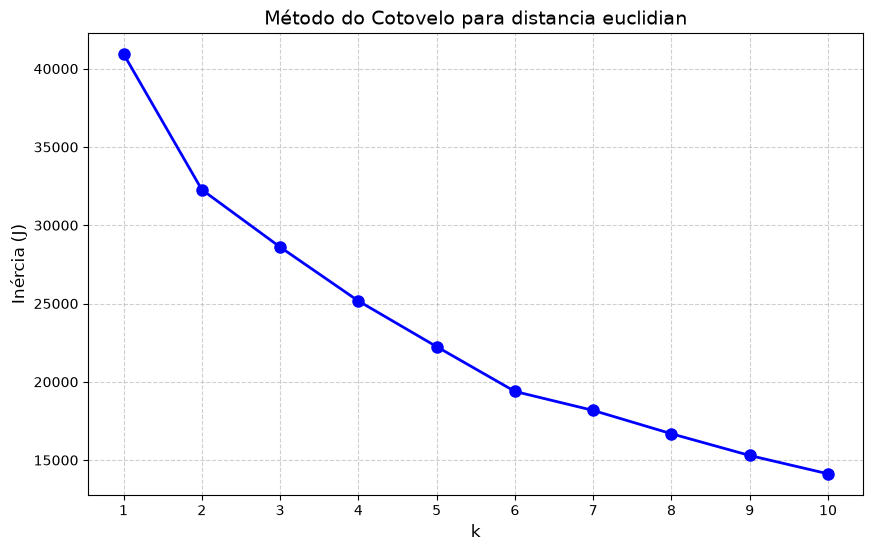

In [225]:
train_and_plotelbow("euclidian")

Podemos ver que a curva de inércia para a distância euclidiana apresenta uma inflexão clara em $k=2$. A redução da inércia após $k=2$ torna-se gradual, caracterizando o ponto de saturação do ganho de informação. 

In [226]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

def plot_clusters_kmeans(k, dist_type, seed):
    kmeans = Kmedias(num_clusters=k, num_iter=100, dist_type=dist_type, seed=seed)
    labels_finais, centroides_finais = kmeans.train(X_scaled)
    centroides_pca = pca.transform(centroides_finais)

    plt.figure(figsize=(10, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_finais, alpha=1.0, edgecolors='w', s=50)
    plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='^', s=100, linewidths=3, label='Centroides (Projetados)')
    plt.title(f'Visualização dos Clusters KMeans com PCA (2D) e distancia {dist_type}', fontsize=14)

    # pegando a quantidade de variancia explicada acumulada em cada PC
    var_cp1 = pca.explained_variance_ratio_[0] * 100
    var_cp2 = pca.explained_variance_ratio_[1] * 100

    plt.xlabel(f'PC1 ({var_cp1:.1f}% da variância mantida)', fontsize=12)
    plt.ylabel(f'PC2 ({var_cp2:.1f}% da variância mantida)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

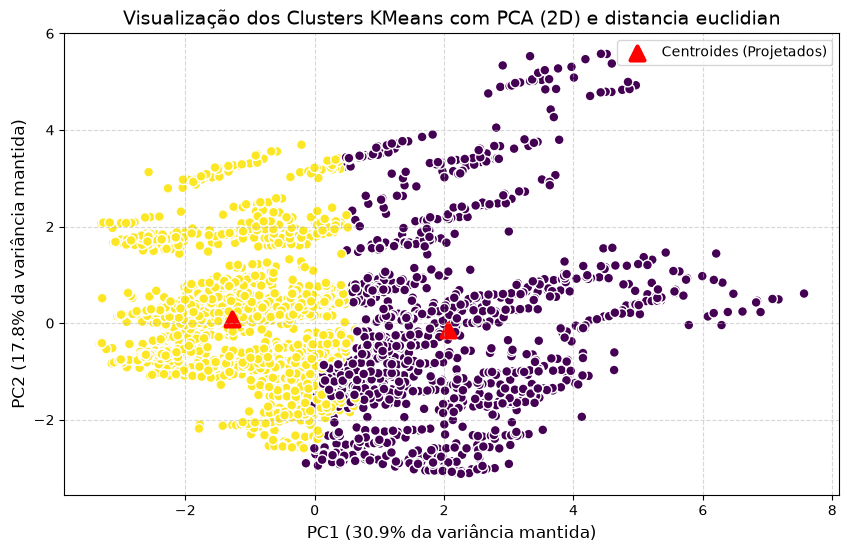

In [227]:
plot_clusters_kmeans(2, "euclidian", 23)

Podemos observar visualmente que a distância euclidiana apresentou um bom desempenho para separação dos clusters, observados em 2 dimesões com o auxílio do PCA

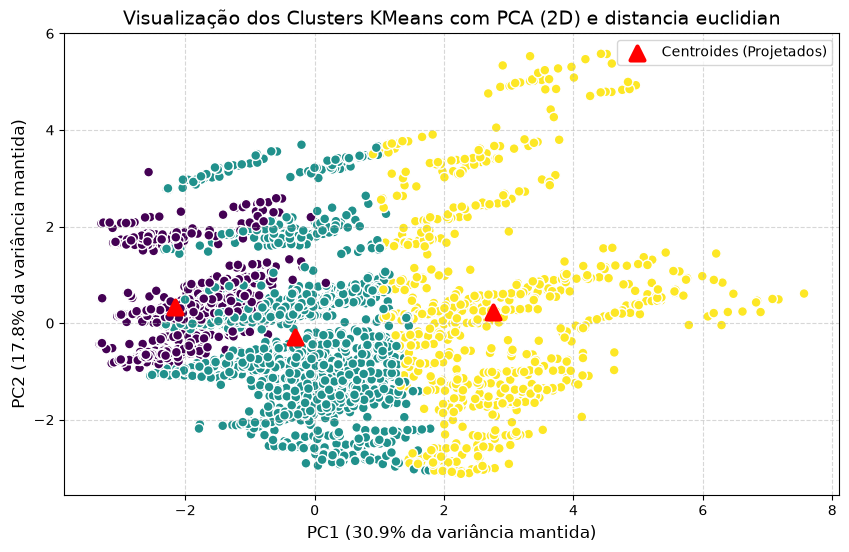

In [228]:
plot_clusters_kmeans(3, "euclidian", 23)

#### Testando com distância de mahalanobis $$d = \sqrt{(x-\mu)^T \Sigma ^{-1} (x-\mu)} $$

K=1 treinado. Inércia: 40937.00
K=2 treinado. Inércia: 38636.84
K=3 treinado. Inércia: 35894.61
K=4 treinado. Inércia: 33278.81
K=5 treinado. Inércia: 30889.02
K=6 treinado. Inércia: 28778.86
K=7 treinado. Inércia: 26470.92
K=8 treinado. Inércia: 24758.97
K=9 treinado. Inércia: 24441.51
K=10 treinado. Inércia: 23792.08


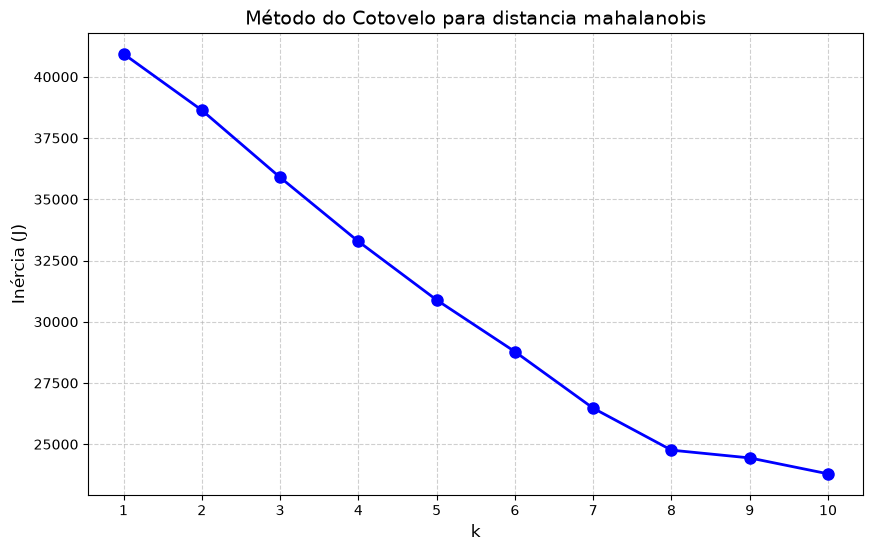

In [229]:
train_and_plotelbow("mahalanobis")

O gráfico do cotovelo com a distância de Mahalanobis exibe um comportamento linear, sem pontos de inflexão acentuados em toda a faixa de $k$ analisada. A ausência de um "cotovelo" definido indica que o modelo não encontra uma estrutura de separação otimizada, independente do número de clusters. Este resultado revela uma ineficácia desta métrica para a base de dados,

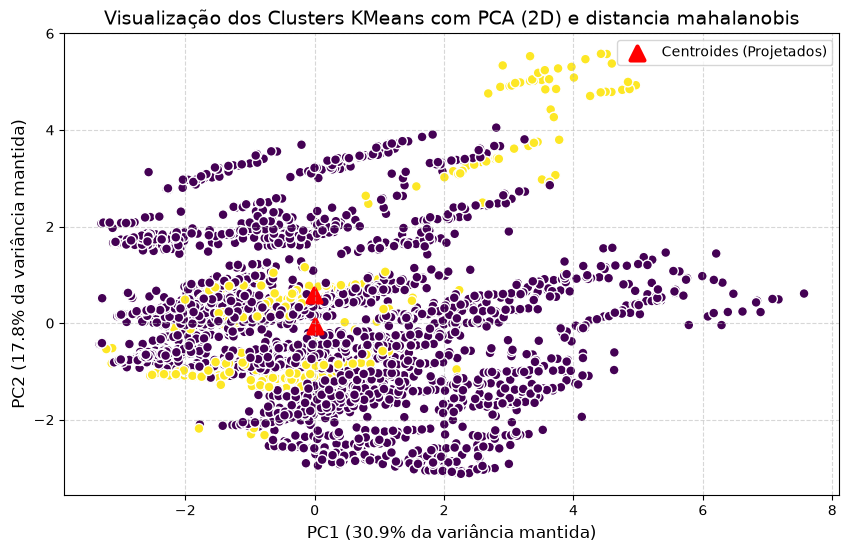

In [230]:
plot_clusters_kmeans(2, "mahalanobis", 23)

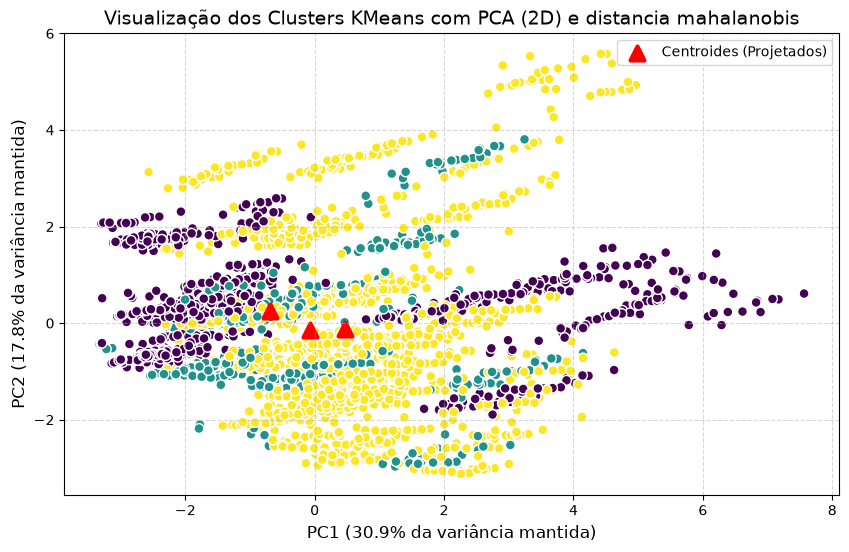

In [231]:
plot_clusters_kmeans(3, "mahalanobis", 23)

#### Testando com distância manhatam $$d = {\sum |x_i-y_i|} $$

K=1 treinado. Inércia: 321048.76
K=2 treinado. Inércia: 226614.23
K=3 treinado. Inércia: 188348.30
K=4 treinado. Inércia: 167519.67
K=5 treinado. Inércia: 152890.18
K=6 treinado. Inércia: 129016.39
K=7 treinado. Inércia: 108887.77
K=8 treinado. Inércia: 100170.46
K=9 treinado. Inércia: 91154.99
K=10 treinado. Inércia: 83795.55


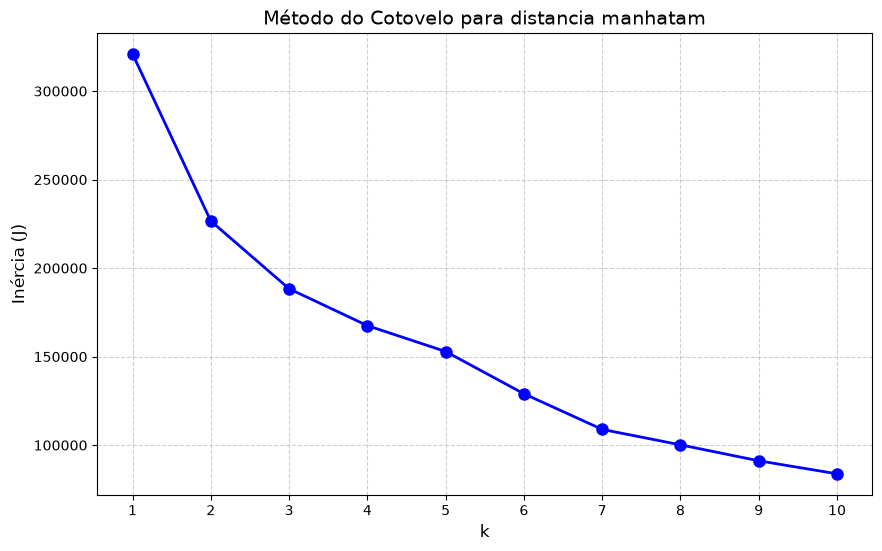

In [232]:
train_and_plotelbow(dist_type="manhatam")

A curva da distância de Manhattan apresenta um comportamento semelhante ao euclidiano, com uma inflexão marcante em $k=2$. A partir deste ponto, a inclinação da curva diminui significativamente, indicando que adições sucessivas de clusters fornecem ganhos marginais na redução da inércia.

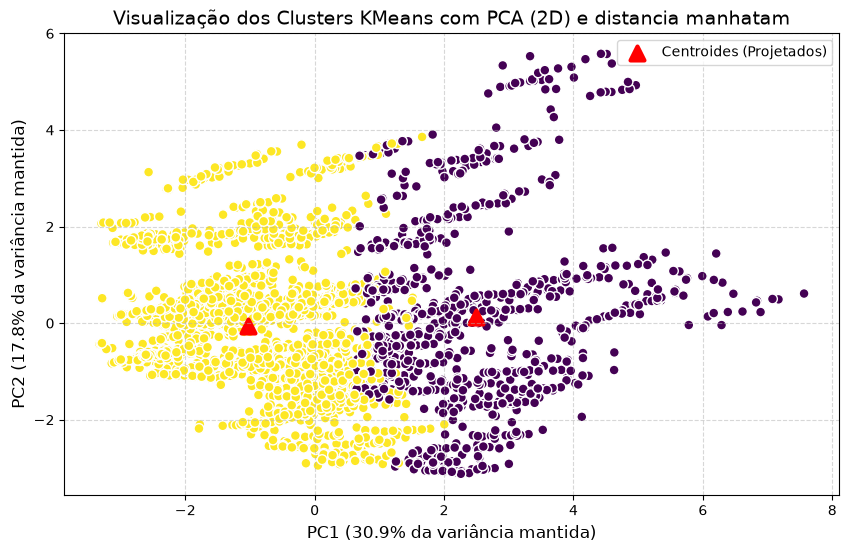

In [233]:
plot_clusters_kmeans(2, "manhatam", 23)

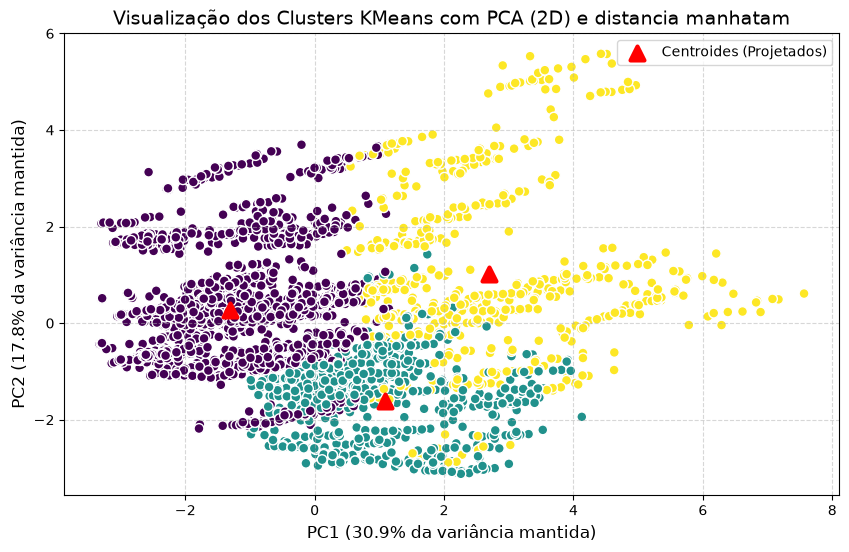

In [234]:
plot_clusters_kmeans(3, "manhatam", 23)

### Análise de diferentes inicializações dos centroides

Apos treinar os modelos com a mesma seed de numero aleatorio para incialização dos centroides para manter um rigor matemático na análise desemepenho, iremos remover a seed e testar o impacto de diferentes inicilizações dos centroides no método que apresentou melhor desemepenho, o que utilizou a distância `eucliadiana` com `K = 2` e  no método que apresentou um comportamento curioso, conseguindo separar razoavelmente em 3 clusters, onde foi utilizado distância `manhatam` com `K = 3`.

Sabendo que o algoritmo é sensível à inicialização dos centroides, podendo acabar convergindo para mínimos locais e não globais, faz-se necessário testar múltiplas inicializações nos 2 cenários descritos anteriormente, ou seja:

- **Primeiro cenário:** Distância Euclidiana com $k=2$.

- **Segundo cenário:** Distância de Manhattan com $k=3$, que demonstrou uma capacidade razoável e curiosa de clusterização do espaço.

In [235]:
def analisar_inicializacoes(X, k, dist_type, num_tentativas=4):
    """
    Roda o K-Médias múltiplas vezes sem seed e plota os resultados.
    """
    fig, axes = plt.subplots(2, 4, figsize=(15, 10))
    fig.suptitle(f'Diferentes inicializações dos centroides\nDistância: {dist_type}\nK = {k}', fontsize=16)
    axes = axes.flatten()
    
    for i in range(num_tentativas):
        # instanciando a classe sem seed para ser de fato aleatorio a cada iteracao
        kmeans = Kmedias(num_clusters=k, num_iter=100, dist_type=dist_type, seed=None)
        labels, centroides = kmeans.train(X)
        centroides_pca = pca.transform(centroides)
        
        # calculo da inercia
        inercia_atual = 0
        for j, ponto in enumerate(X):
            centroide_atribuido = centroides[labels[j]]
            if dist_type == "euclidian":
                dist = kmeans._euclidian(ponto, centroide_atribuido)
            elif dist_type == "manhatam":
                dist = kmeans._manhatam(ponto, centroide_atribuido)
            inercia_atual += dist ** 2
            
        # plotando em 2D com ajuda do PCA
        axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, alpha=1.0, edgecolors='w', s=50)
        axes[i].scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='^', s=100, linewidths=3, label='centroides')
        axes[i].legend()

        # pegando a quantidade de variancia explicada acumulada em cada PC
        var_cp1 = pca.explained_variance_ratio_[0] * 100
        var_cp2 = pca.explained_variance_ratio_[1] * 100

        plt.xlabel(f'PC1 ({var_cp1:.1f}% da variância mantida)', fontsize=12)
        plt.ylabel(f'PC2 ({var_cp2:.1f}% da variância mantida)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)

        axes[i].set_title(f'Tentativa {i+1}\nInércia: {inercia_atual:.2f}', fontsize=12)
        axes[i].grid(True)
        
            
    plt.tight_layout()
    plt.show()
    

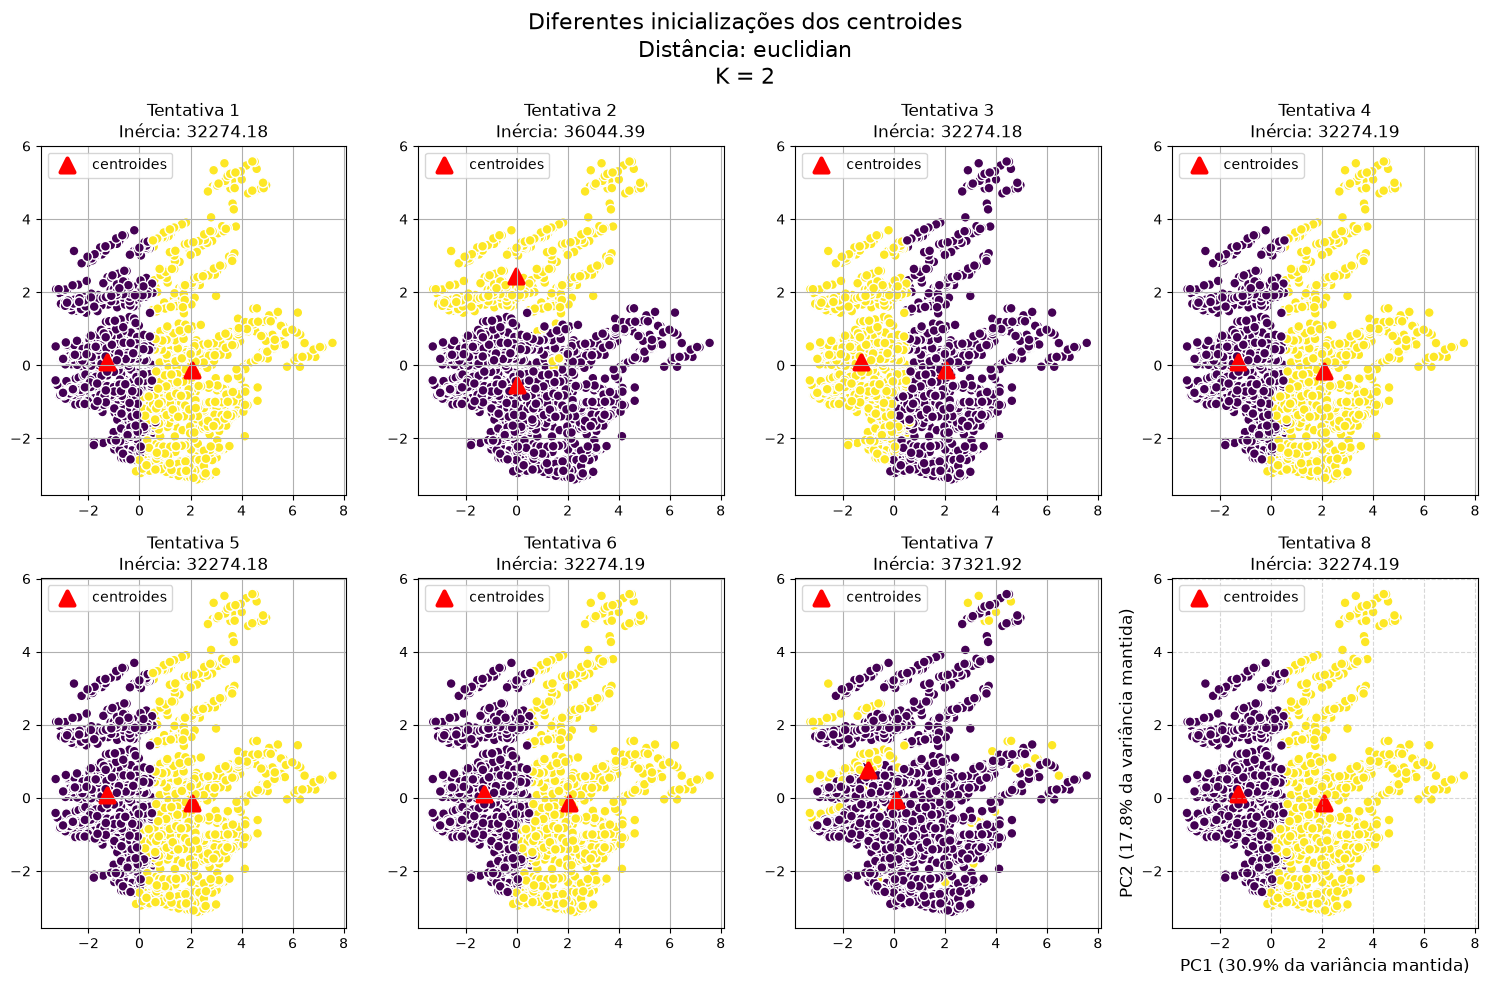

In [236]:
analisar_inicializacoes(X_scaled, k=2, dist_type="euclidian", num_tentativas=8)

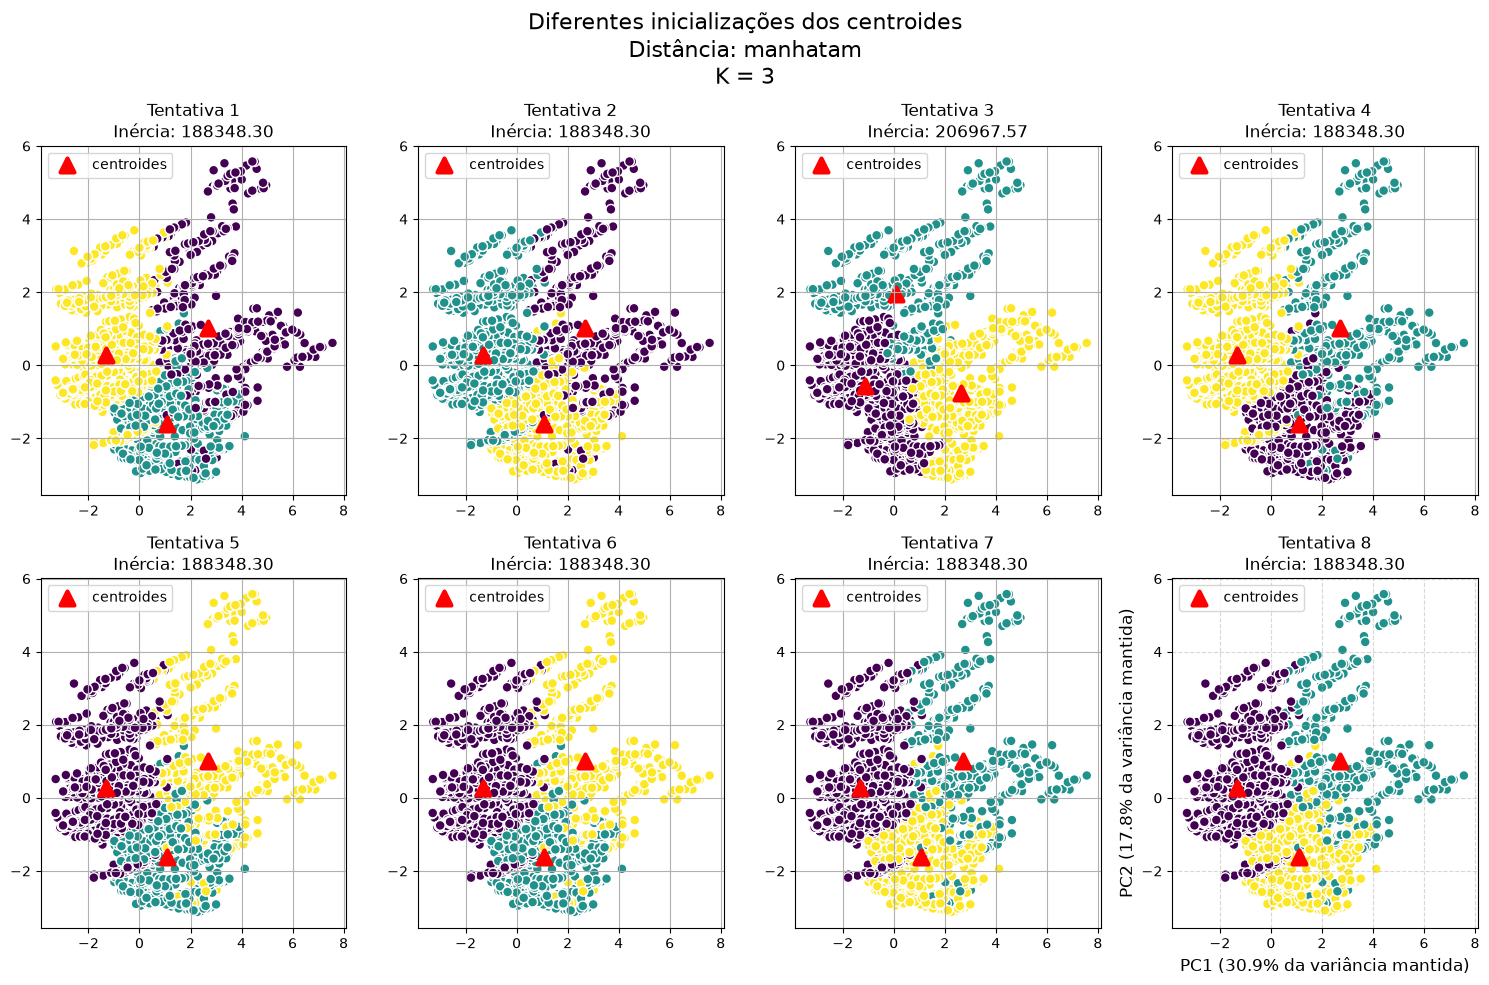

In [237]:
analisar_inicializacoes(X_scaled, k=3, dist_type="manhatam", num_tentativas=8)

## Analise da probabilidade de Churn de cada cluster gerado pelo Kmeans com diferentes metricas de distancia

### Distancia euclidiana

In [238]:
kmeans_euclid = Kmedias(num_clusters=2, num_iter=100, dist_type="euclidian", seed=23)
labels_euclid, centroides_euclid = kmeans_euclid.train(X_scaled)

data['Cluster_Euclidiana'] = labels_euclid

print("--- ANÁLISE: DISTÂNCIA EUCLIDIANA ---")
analise_euclid = data.groupby('Cluster_Euclidiana')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_euclid.index:
    taxa = analise_euclid.loc[cluster_id, 'mean'] * 100
    qtd = analise_euclid.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)")

--- ANÁLISE: DISTÂNCIA EUCLIDIANA ---
Cluster 0: 0.75% de probabilidade de Churn (1208 clientes)
Cluster 1: 25.03% de probabilidade de Churn (1942 clientes)


Podemos observar que a distância euclidiana demonstrou um bom desempenho na clusterização dos clientes, estabelecendo uma clara diferenciação de risco: o Cluster 0 reteve uma probabilidade de churn reduzida (0,75%), enquanto o Cluster 1 concentrou a maior propensão à evasão (25,03%). Este desempenho superior se dá pela adequação da métrica à geometria dos dados, que permitiu ao algoritmo identificar fronteiras de decisão mais lineares.

### Distancia de mahalanobis

In [239]:
kmeans_mahal = Kmedias(num_clusters=2, num_iter=100, dist_type="mahalanobis", seed=23)
labels_mahal, centroides_mahal = kmeans_mahal.train(X_scaled)

data['Cluster_Mahalanobis'] = labels_mahal

print("--- ANÁLISE: DISTÂNCIA DE MAHALANOBIS ---")
analise_mahal = data.groupby('Cluster_Mahalanobis')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_mahal.index:
    taxa = analise_mahal.loc[cluster_id, 'mean'] * 100
    qtd = analise_mahal.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)")

--- ANÁLISE: DISTÂNCIA DE MAHALANOBIS ---
Cluster 0: 15.30% de probabilidade de Churn (2823 clientes)
Cluster 1: 19.27% de probabilidade de Churn (327 clientes)


A distância de Mahalanobis apresentou um desempenho limitado, com probabilidades de churn de 15,30% e 19,27% entre os clusters. 

Este resultado revela que a métrica não é a mais adequada nesse cenário visando segmentar os clientes conforme a propensão à evasão. 

O baixo desempenho é justificado pela análise exploratória feita previemante no pairplot, a qual revelou distribuições não normais e assimétricas. 

Como a métrica de Mahalanobis fundamenta seus cálculos na premissa de normalidade multivariada, a estrutura irregular dos dados impediu a definição de fronteiras de decisão adequadas, tornando a abordagem ineficaz para este conjunto de dados.

#### Distancia manhatam

Manhatam com K = 2

In [240]:
kmeans_manh = Kmedias(num_clusters=2, num_iter=100, dist_type="manhatam", seed=23)
labels_manh, centroides_manh = kmeans_manh.train(X_scaled)

data['Cluster_Manhattan'] = labels_manh

print("--- ANÁLISE: DISTÂNCIA DE MANHATTAN ---")
analise_manh = data.groupby('Cluster_Manhattan')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_manh.index:
    taxa = analise_manh.loc[cluster_id, 'mean'] * 100
    qtd = analise_manh.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)")

--- ANÁLISE: DISTÂNCIA DE MANHATTAN ---
Cluster 0: 0.33% de probabilidade de Churn (923 clientes)
Cluster 1: 22.09% de probabilidade de Churn (2227 clientes)


Manhatam com K = 3

In [241]:
kmeans_manh = Kmedias(num_clusters=3, num_iter=100, dist_type="manhatam", seed=23)
labels_manh, centroides_manh = kmeans_manh.train(X_scaled)

data['Cluster_Manhattan'] = labels_manh

print("--- ANÁLISE: DISTÂNCIA DE MANHATTAN ---")
analise_manh = data.groupby('Cluster_Manhattan')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_manh.index:
    taxa = analise_manh.loc[cluster_id, 'mean'] * 100
    qtd = analise_manh.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)")

--- ANÁLISE: DISTÂNCIA DE MANHATTAN ---
Cluster 0: 26.18% de probabilidade de Churn (1837 clientes)
Cluster 1: 1.58% de probabilidade de Churn (698 clientes)
Cluster 2: 0.49% de probabilidade de Churn (615 clientes)


Podemos observar que com K = 2 o grupo separado pelo cluster 1 possui uma maior probabilidade de churn em relação ao separado pelo cluster 0 (22,09% vs 0,33%), mostrando que a distância de manhatam é uma boa abordagem para o problema.

Ja no segundo caso com K = 3, podemos ver que no novo cluster criado, há pontos atribuidos que antes pertenciam a ambos os clusters ja existentes, tendo em vista que o numero de clientes em cada um diminuiu. Isso revela que há uma possível terceira categoria de clientes, sendo ela uma faixa de transição com perfil de risco moderado, o que permite isolar com maior precisão o segmento de alta evasão dos usuários de comportamento mais estável.

## Implementação do Hierarquico aglomerativo (bottom up)

O algoritmo segue o seguinte fluxo:

1. Inicia-se com pontos individuais, ou seja, cada ponto de dados é o seu próprio cluster. Por exemplo, caso existam 5 pontos de dados, inicia-se com 5 clusters, cada um contendo exatamente um ponto.
2. Calcula-se a distância entre todos os pares de clusters. Inicialmente, como cada cluster possui apenas um ponto, esta será simplesmente a distância entre dois pontos.
3. Identificam-se os dois clusters que apresentam a menor distância entre si, unindo-os para formar um único cluster.
4. Após a fusão, passa-se a ter um cluster a menos no total. As distâncias entre o novo cluster e os outros clusters restantes são recalculadas.
5. Os passos 3 e 4 são repetidos, juntando-se continuamente os clusters mais próximos e recalculando-se as distância, até que todos os pontos estejam agrupados em um único e grande cluster final.


Algo que interfere significantemente no algoritmo é o método de critério de distância usado para unir os clusters.
Os métodos que serão listados a seguir são usados para computar a distância $d(s,t)$ entre dois clusters $s$ e $t$. O algoritmo começa com uma "floresta" de clusters que serão usados na hierarquia que será formada. Quando dois clusters $s$ e $t$ da floresta são combinados em um cluster $u$, $s$ e $t$ são removidos da floresta e $u$ é adicionado. Quando há apenas um cluster restante na floresta, o algortimo para e esse cluster se torna a raíz.

Uma matriz de distâncias é mantida a cada iteração. O valor $d[i, j]$ corresponde a distância entre o cluster $i$ e $j$ na floresta original. A cada iteração, o algoritmo atualiza a matriz de distancias para indicar a distância do novo cluster formado $u$ em relação aos demais na floresta.

Assuma $v$ sendo qualquer outro cluster na floresta menos $u$, os seguintes métodos são empregados para calcular a distância entre $u$ e $v$. Lembrando que $u$ é resultante da junção de $s$ e $t$.

obs:  $|*|$ é o operador de cardinalidade, ou seja, indica a quantidade de pontos em um cluster

- single: $$d(u,v) = min(dist(u[i], v[j]))$$
- complete: $$d(u,v) = max(dist(u[i], v[j]))$$
- avarege: $$d(u,v) = \sum_{ij} \frac{d(u[i], v[j])}{(|u| * |v|)}$$
- ward: $$d(u,v) = \sqrt{\frac{|v| + |s|}{T} d(v,s)^2 + \frac{|v| + |t|}{T} d(v,t)^2 - \frac{|v|}{T} d(s,t)^2}$$ onde $T = |v| + |s| + |t|$

In [242]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import scipy.cluster.hierarchy as sch

In [243]:
methods = ['single', 'complete', 'average', 'ward']

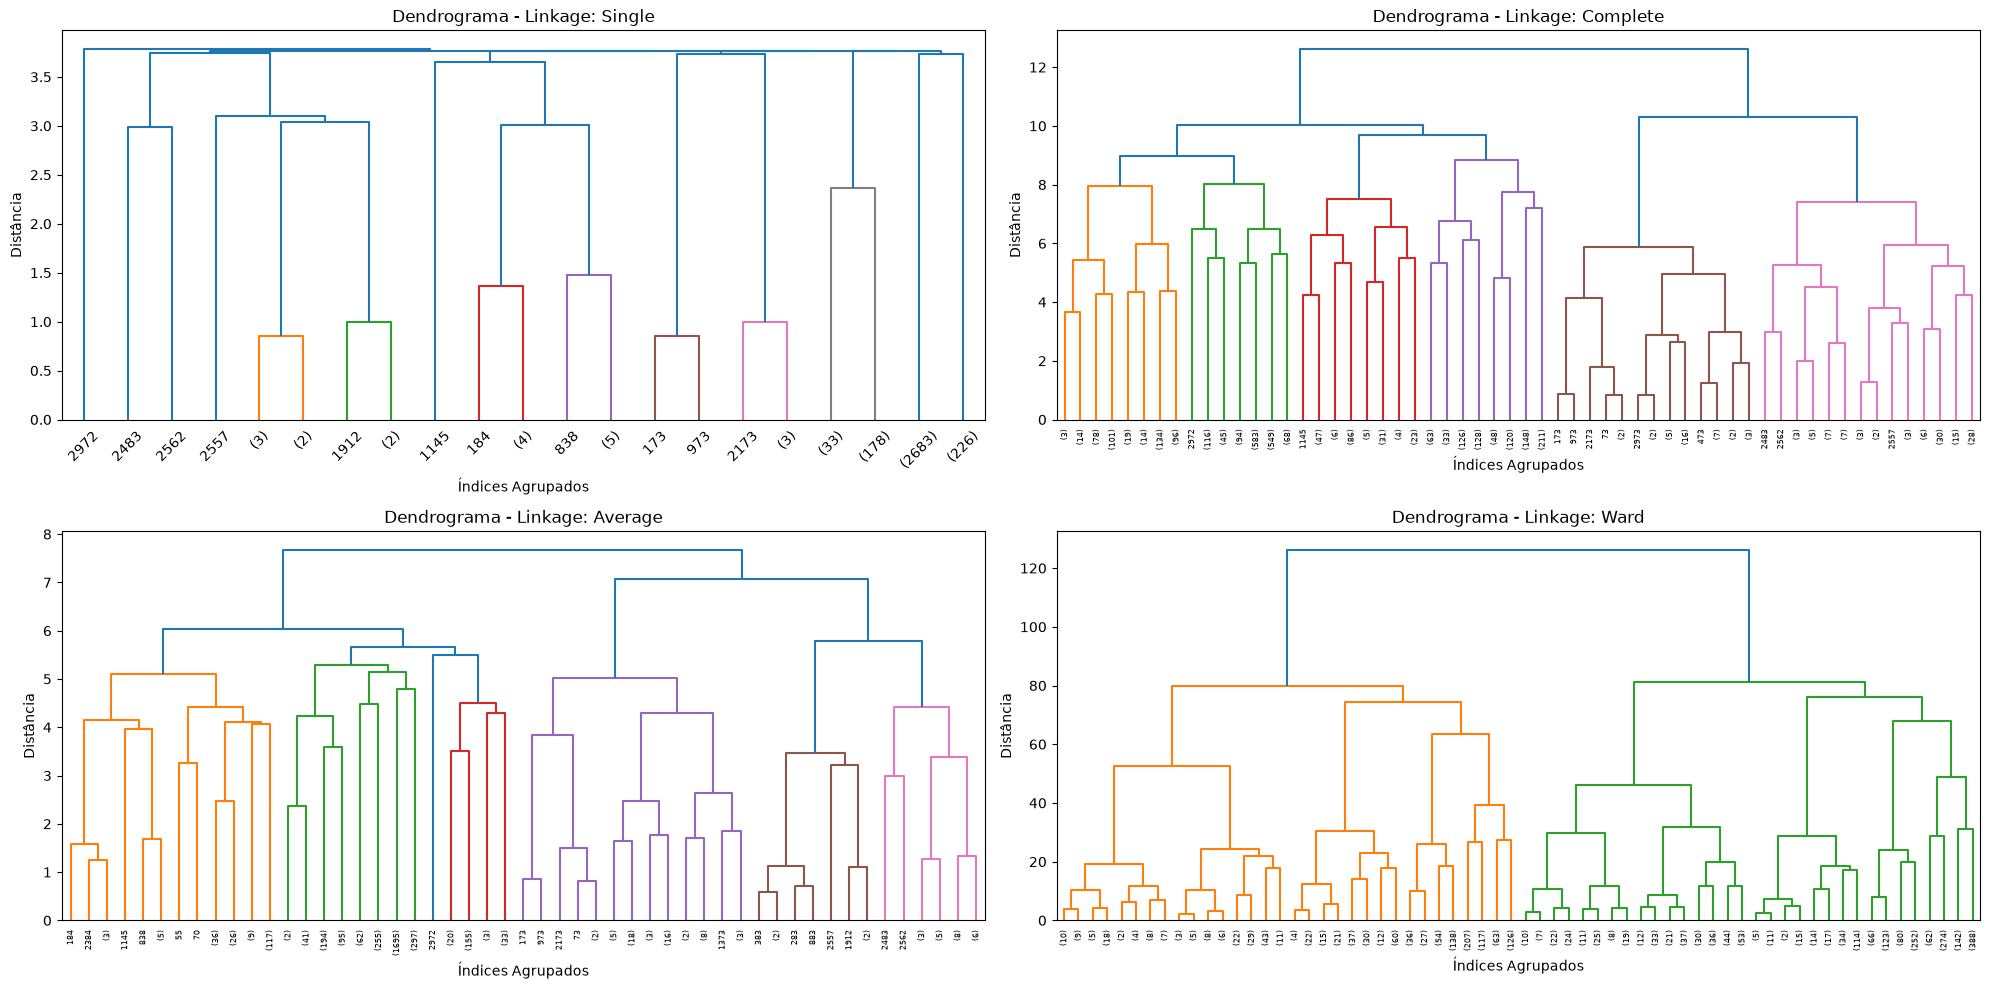

In [244]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for i, method in enumerate(methods):
    Z = sch.linkage(X_scaled, method=method)
    
    sch.dendrogram(Z, ax=axes[i], truncate_mode='level', p=5)
    
    axes[i].set_title(f'Dendrograma - Linkage: {method.capitalize()}')
    axes[i].set_xlabel('Índices Agrupados')
    axes[i].set_ylabel('Distância')
    
 

plt.tight_layout()
plt.show()

Podemos observar o seguinte para cada método aplicado

**Método Single:**
- Apresenta um forte efeito de "escada", unindo os dados de forma sequencial.
- Tende a formar um único cluster majoritário, separando pontos fora da curva (*outliers*) um a um.
- É a topologia que se demonstrou menos adequada para a clusterização de perfis nesta base de dados.

**Método Complete:**
- Força a criação de grupos esféricos e densos ao calcular a distância máxima entre os pontos.
- Gera uma árvore com muitas sub-ramificações que atingem rapidamente o topo do gráfico.
- Pode dividir grupos que naturalmente pertenceriam juntos devido à sensibilidade às extremidades dos clusters.

**Método Average:**
- Atua como um meio-termo matemático entre os extremos dos métodos *Single* e *Complete*.
- Agrupa os clientes calculando a distância média entre todos os pares.
- Constrói uma topologia útil, mas ainda preserva galhos irregulares na base da árvore.

**Método de Ward:**
- Agrupa os clientes minimizando a variância interna, gerando os clusters mais homogêneos possíveis.
- Produz ramificações espessas e simétricas, facilitando a identificação visual do ponto de corte ideal ($k$).
- É o método que se demonsrou mais adequado ao conjunto para isolar as fronteiras do risco de *churn*.

In [245]:
for m in methods:
    model = AgglomerativeClustering(n_clusters=2, linkage=m)
    
    # Salvando os rótulos de cada método para comparar o Churn depois, 
    labels_atuais = model.fit_predict(X_scaled)
    data[f'Cluster_{m}'] = labels_atuais

In [246]:
data

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,...,Age,Customer Value,Churn,Cluster_Euclidiana,Cluster_Mahalanobis,Cluster_Manhattan,Cluster_single,Cluster_complete,Cluster_average,Cluster_ward
0,8,0,38,0,4370,71,5,17,3,1,...,30,197.640,0,1,0,0,0,1,1,0
1,0,0,39,0,318,5,7,4,2,1,...,25,46.035,0,1,0,0,0,1,1,0
2,10,0,37,0,2453,60,359,24,3,1,...,30,1536.520,0,0,0,1,0,1,1,1
3,10,0,38,0,4198,66,1,35,1,1,...,15,240.020,0,1,0,0,0,1,1,0
4,3,0,38,0,2393,58,2,33,1,1,...,15,145.805,0,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,...,25,721.980,0,0,0,2,0,1,1,1
3146,17,0,17,1,9237,177,80,42,5,1,...,55,261.210,0,0,0,2,0,1,1,0
3147,13,0,18,4,3157,51,38,21,3,1,...,30,280.320,0,1,1,0,0,1,1,0
3148,7,0,11,2,4695,46,222,12,3,1,...,30,1077.640,0,0,1,1,0,1,1,0


In [247]:
# Analisando a taxa de Churn para o metodo Single
analise_single = data.groupby('Cluster_single')['Churn'].mean()
print("Taxa de Churn por grupo (Metodo Single):")
print(analise_single)
print("-" * 30)
print('\n')

# Analisando a taxa de Churn para o metodo Complete
analise_single = data.groupby('Cluster_complete')['Churn'].mean()
print("Taxa de Churn por grupo (Metodo Complete):")
print(analise_single)
print("-" * 30)
print('\n')

# Analisando a taxa de Churn para o metodo Average
analise_single = data.groupby('Cluster_average')['Churn'].mean()
print("Taxa de Churn por grupo (Metodo Average):")
print(analise_single)
print("-" * 30)
print('\n')
# Analisando a taxa de Churn para o metodo Ward
analise_ward = data.groupby('Cluster_ward')['Churn'].mean()
print("Taxa de Churn por grupo (Metodo Ward):")
print(analise_ward)
print("-" * 30)


Taxa de Churn por grupo (Metodo Single):
Cluster_single
0    0.156875
1    1.000000
Name: Churn, dtype: float64
------------------------------


Taxa de Churn por grupo (Metodo Complete):
Cluster_complete
0    0.000000
1    0.165275
Name: Churn, dtype: float64
------------------------------


Taxa de Churn por grupo (Metodo Average):
Cluster_average
0    0.000000
1    0.162029
Name: Churn, dtype: float64
------------------------------


Taxa de Churn por grupo (Metodo Ward):
Cluster_ward
0    0.245605
1    0.005177
Name: Churn, dtype: float64
------------------------------


**Comentários acerca da taxa de churn por grupo dado cada método:**

- Método Single: Utilizando o método single, o algoritmo apresenteu um desempenho ruim pois acabou por classificar apenas 1 indivíduo no cluster 1, o qual acabou contribuindo unitariamente para a taxa de 100% de churn nesse cluster, já no cluster 0, podemos ver que representa a quantidade da porcentagem original de churn do conjunto de dados, tendo em vista que todas as outras amostras foram classificadas nele.

- Método Complete: Cluster 0 com 0% de Churn e Cluster 1 com 16.53%, apresentando uma boa capacidade de separação espacial.

- Método Average: Resultado bastante similar ao com Complete, sendo o Cluster 0 com 0% de Churn e o Cluster 1 com 16.2%.

- Método ward: Apresentou um otimo resultado, com o Cluster 0 com 24.5% de Churn e o Cluster 1 com 0.5%.

Ou seja, com isso, conseguimos concluir que os métodos `Ward` e `Complete` foram os que apresenteram o melhor desempenho.


Plotando os clusters gerados por cada método

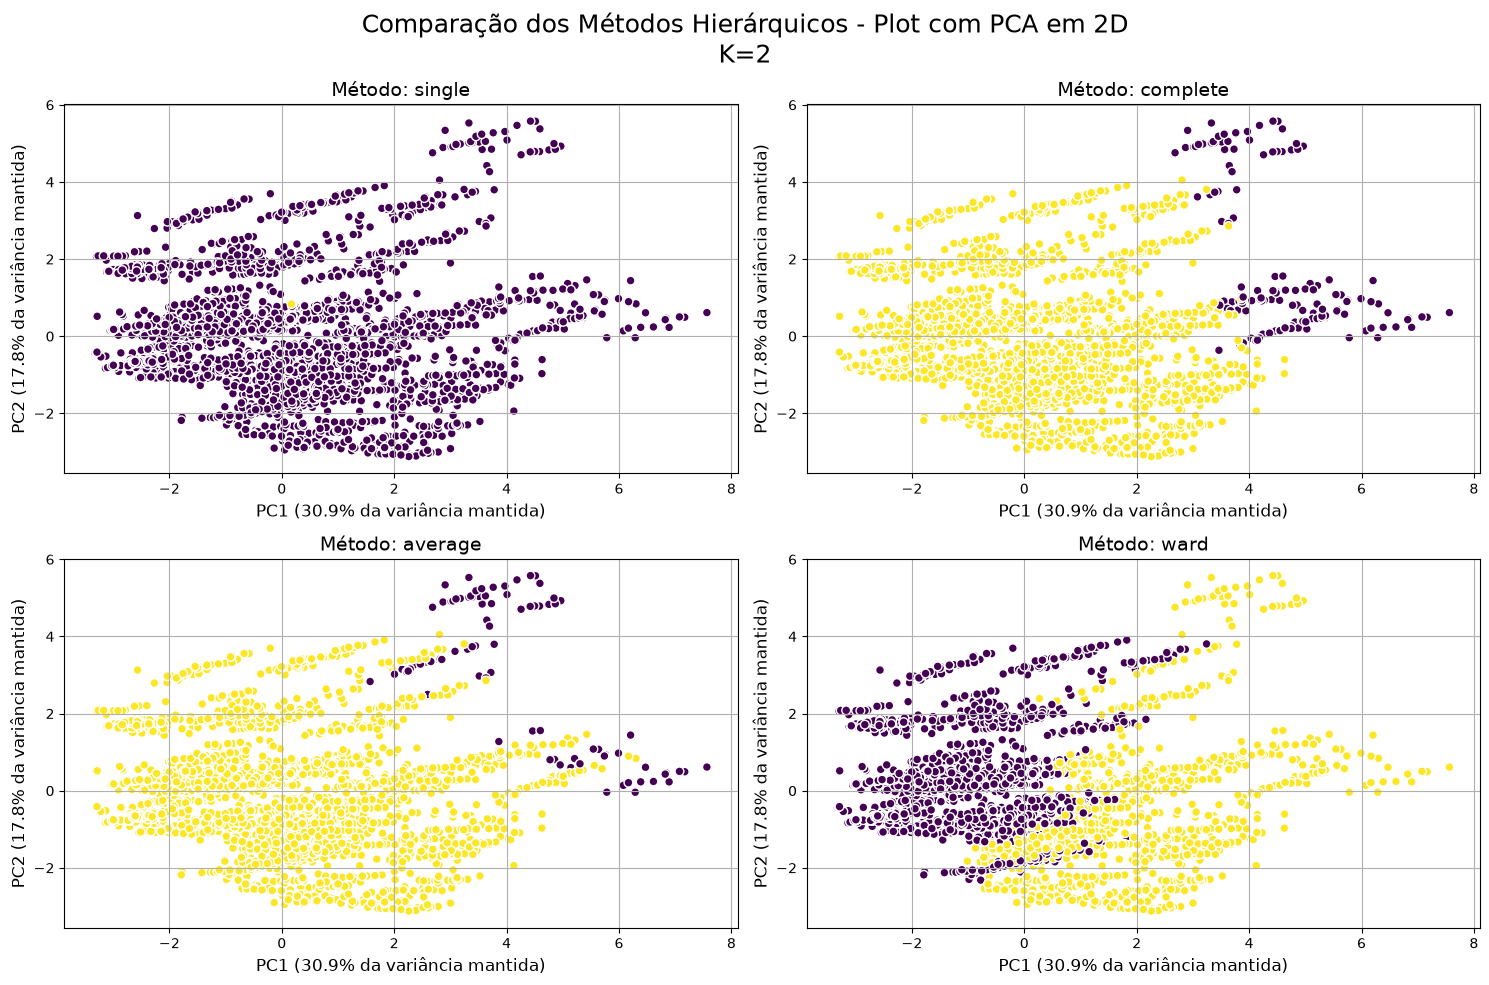

In [248]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, m in enumerate(methods):
    labels_atuais = data[f'Cluster_{m}']
    
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_atuais, cmap='viridis', alpha=1.0, s=40, edgecolors='w')
    
    axes[i].set_title(f'Método: {m}', fontsize=14)
    var_cp1 = pca.explained_variance_ratio_[0] * 100
    var_cp2 = pca.explained_variance_ratio_[1] * 100

    axes[i].set_xlabel(f'PC1 ({var_cp1:.1f}% da variância mantida)', fontsize=12)
    axes[i].set_ylabel(f'PC2 ({var_cp2:.1f}% da variância mantida)', fontsize=12)
    axes[i].grid(True)

# 3. Formatação final do painel inteiro
plt.suptitle('Comparação dos Métodos Hierárquicos - Plot com PCA em 2D\nK=2', fontsize=18)
plt.tight_layout()
plt.show()

O gráfico dos clusters para cada método confirma o que foi comentado anteriormente acerca de cada um, tornando possível visualizar que ao utilizar o método `single` uma única amostra foi classificada no Cluster 1. Ademais, podemos ver que o método `ward` apresenta uma melhor separação visual entre os grupos, a qual se mostra bem semelhante à obtida com o KMeans com distâncias Euclidiana e Manhatam.

A título de verificação, o método `average` foi testado com $k=3$, motivado pela topologia visual do dendrograma. No entanto, a análise estatística revela que essa subdivisão gera redundância: os Clusters 1 e 2 apresentam comportamento idêntico quanto ao risco de evasão (ambos com 0% de probabilidade de churn). Essa ausência de diferenciação comprova o valor de $k=2$ como o ideal.

In [249]:
hc_avg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels_avg_k3 = hc_avg.fit_predict(X_scaled)

data['Cluster_average_k3'] = labels_avg_k3

print("ANÁLISE: HIERÁRQUICO (AVERAGE k=3)")
analise_avg = data.groupby('Cluster_average_k3')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_avg.index:
    taxa = analise_avg.loc[cluster_id, 'mean'] * 100
    qtd = analise_avg.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)")

ANÁLISE: HIERÁRQUICO (AVERAGE k=3)
Cluster 0: 16.20% de probabilidade de Churn (3055 clientes)
Cluster 1: 0.00% de probabilidade de Churn (33 clientes)
Cluster 2: 0.00% de probabilidade de Churn (62 clientes)


## Analisando o perfil dos clientes

Para analisar o perfil dos clientes, será utilizado o módelo que apresentou melhor desempenho, sendo ele o KMeans com `K=2` e métrica de distância `euclidiana`.

In [250]:
kmeans_euclid_k2 = Kmedias(num_clusters=2, num_iter=100, dist_type="euclidian", seed=23)
labels_euclid_k2, centroides_euclid_k2 = kmeans_euclid_k2.train(X_scaled)

data['Cluster_Euclidiana_k2'] = labels_euclid_k2

print("ANÁLISE: KMeans (euclidiana k=2)")
analise_euclid_k2 = data.groupby('Cluster_Euclidiana_k2')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_euclid_k2.index:
    taxa = analise_euclid_k2.loc[cluster_id, 'mean'] * 100
    qtd = analise_euclid_k2.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)\n")

print("--- PERFIL MÉDIO DE CONSUMO POR CLUSTER ---")

colunas_antigas = [col for col in data.columns if col.startswith('Cluster_') and col != 'Cluster_Euclidiana_k2']
perfil_k2 = data.drop(columns=colunas_antigas).groupby('Cluster_Euclidiana_k2').mean()
display(perfil_k2.T)

ANÁLISE: KMeans (euclidiana k=2)
Cluster 0: 0.75% de probabilidade de Churn (1208 clientes)

Cluster 1: 25.03% de probabilidade de Churn (1942 clientes)

--- PERFIL MÉDIO DE CONSUMO POR CLUSTER ---


Cluster_Euclidiana_k2,0,1
Call Failure,11.630795,5.138002
Complains,0.020695,0.111226
Subscription Length,33.956954,31.661689
Charge Amount,1.892384,0.352214
Seconds of Use,8167.331126,2174.105046
Frequency of use,119.254139,38.487127
Frequency of SMS,146.461921,27.587539
Distinct Called Numbers,35.910596,15.796087
Age Group,2.890728,2.785788
Tariff Plan,1.175497,1.016993


Ao analisar o valor médio de cada feature por cluster, podemos perceber que:


- Os clientes com alto consumo (Seconds of Use) foram classificados majoritariamente no Cluster 0, grupo que apresenta uma taxa de evasão quase nula (0,75%).

- O cluster 0 apresenta um perfil empresarial, dado a grande quantidade de números distintos apresentada, além de apresentar um valor baixo de churn mesmo com uma quantidade razoável de falhas, também mostra um grande valor agregado de cliente.

- O cluster 1 apresenta um perfil de usuários móvel, dado um menor valor agregado de cliente, uma taxa maior de reclamações, uma frequência de uso bem menor e um plano de tarifa mais próximo do pré pago.

### Analisando com os dados não padronizados

/home/mateus/UFC/StochasticProcesses/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


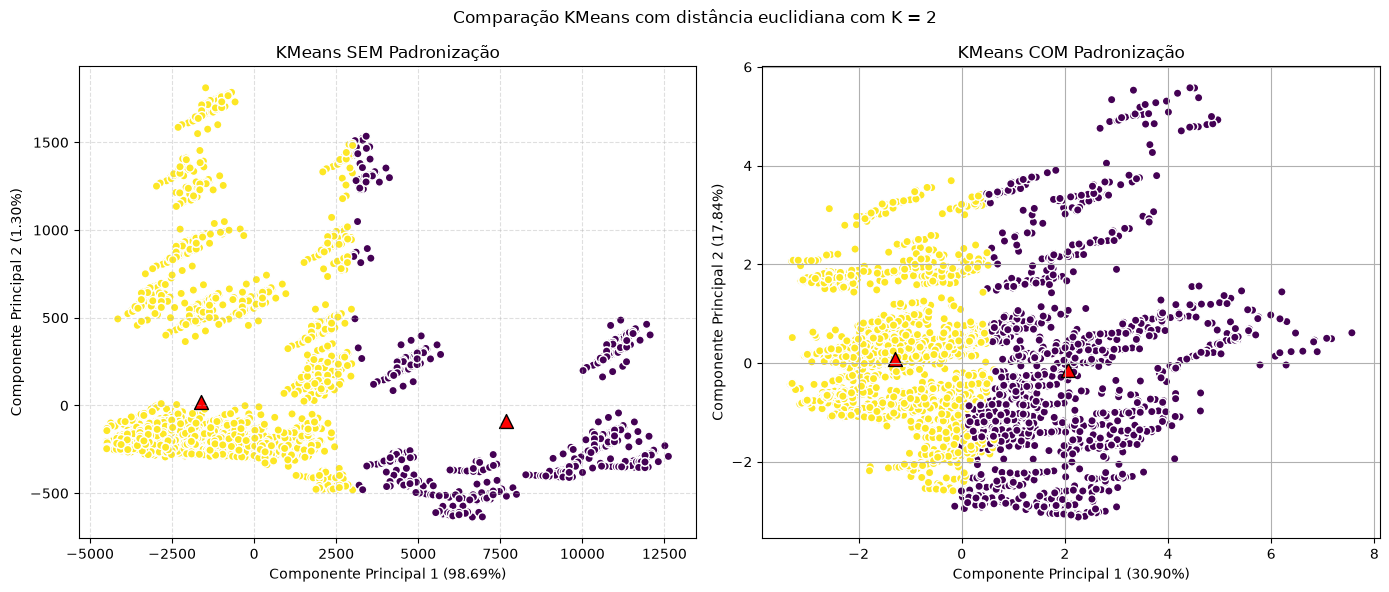

In [255]:
kmeans_sem_escala = Kmedias(num_clusters=2, num_iter=100, dist_type="euclidian", seed=23)
labels_sem_escala, centroides_sem_escala = kmeans_sem_escala.train(X.values) 

pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)
centroides_pca_raw = pca_raw.transform(centroides_sem_escala)

var_raw_pc1 = pca_raw.explained_variance_ratio_[0] * 100
var_raw_pc2 = pca_raw.explained_variance_ratio_[1] * 100

var_pca_pc1 = pca.explained_variance_ratio_[0] * 100
var_pca_pc2 = pca.explained_variance_ratio_[1] * 100
centroides_pca_padronizados = pca.transform(centroides_euclid_k2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_raw[:, 0], X_pca_raw[:, 1], c=labels_sem_escala, cmap='viridis', alpha=1.0, edgecolors='w')
axes[0].scatter(centroides_pca_raw[:, 0], centroides_pca_raw[:, 1], c='red', s=100, marker='^', edgecolors='black')
axes[0].set_title('KMeans SEM Padronização')
axes[0].set_xlabel(f'Componente Principal 1 ({var_raw_pc1:.2f}%)')
axes[0].set_ylabel(f'Componente Principal 2 ({var_raw_pc2:.2f}%)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=data['Cluster_Euclidiana_k2'], cmap='viridis', alpha=1.0, edgecolors='w')
axes[1].scatter(centroides_pca_padronizados[:, 0], centroides_pca_padronizados[:, 1], c='red', s=100, marker='^', edgecolors='black')
axes[1].set_title('KMeans COM Padronização')
axes[1].set_xlabel(f'Componente Principal 1 ({var_pca_pc1:.2f}%)')
axes[1].set_ylabel(f'Componente Principal 2 ({var_pca_pc2:.2f}%)')
axes[1].grid(True)

plt.suptitle('Comparação KMeans com distância euclidiana com K = 2')
plt.tight_layout()
plt.show()

Podemos ver que a comparação visual evidencia o impacto da padronização em algoritmos baseados em distâncias. No cenário sem escala (à esquerda), a variável de maior magnitude absoluta monopoliza o agrupamento, esmagando a variância das demais métricas e gerando uma fronteira de decisão quase unidimensional. Em contraste, a padronização dos dados (à direita) equaliza o peso geométrico de todos os atributos na composição do espaço. Isso permite que o modelo capture a verdadeira estrutura multidimensional da base, resultando em uma segregação equilibrada e com centroides mais ajustados ao centro de massa dos diferentes perfis comportamentais.

In [258]:
data['Cluster_Euclidiana_k2_not_norm'] = labels_sem_escala

print("ANÁLISE: KMeans (euclidiana k=2) não Padronizado")
analise_euclid_k2_not_norm = data.groupby('Cluster_Euclidiana_k2_not_norm')['Churn'].agg(['mean', 'count'])

for cluster_id in analise_euclid_k2_not_norm.index:
    taxa = analise_euclid_k2_not_norm.loc[cluster_id, 'mean'] * 100
    qtd = analise_euclid_k2_not_norm.loc[cluster_id, 'count']
    print(f"Cluster {cluster_id}: {taxa:.2f}% de probabilidade de Churn ({qtd} clientes)\n")


colunas_antigas = [col for col in data.columns if col.startswith('Cluster_') and col != "Cluster_Euclidiana_k2_not_norm"]
perfil_k2 = data.drop(columns=colunas_antigas).groupby('Cluster_Euclidiana_k2_not_norm').mean()
display(perfil_k2.T)

ANÁLISE: KMeans (euclidiana k=2) não Padronizado
Cluster 0: 0.00% de probabilidade de Churn (553 clientes)

Cluster 1: 19.06% de probabilidade de Churn (2597 clientes)



Cluster_Euclidiana_k2_not_norm,0,1
Call Failure,14.338156,6.199076
Complains,0.034358,0.085483
Subscription Length,34.025316,32.226030
Charge Amount,2.273056,0.659607
Seconds of Use,12126.584087,2842.605699
Frequency of use,165.547920,49.000000
Frequency of SMS,82.269439,71.238352
Distinct Called Numbers,44.692586,18.999230
Age Group,3.150090,2.757027
Tariff Plan,1.094033,1.074317


A ausência de padronização distorce os algoritmos baseados em distância
(exemplificados acima pelo KMédias com distância euclidiana), pois o cálculo da
distância espacial eleva as diferenças brutas ao quadrado nesse caso, concedendo
peso matemático desproporcional a atributos de grande magnitude absoluta. A
tabela mostra na prática esse viés, o modelo foi dominado
pela escala da variável `Seconds of Use` (na casa dos milhares), tornando-se
cego para as outras features, como a variação decimal em
`Complains` ou as pequenas unidades de `Call Failure`. Como resultado, o
algoritmo se comportou como um filtro unidimensional, isolando uma
minoria de alto consumo no Cluster 0 (com média de 12.126 segundos de uso) e agrupando
o restante da base de forma genérica no Cluster 1. Essa
distorção matemática inviabilizou a descoberta de uma estrutura multivariada dos
dados, mascarando os reais perfis comportamentais.